# Часть 2. `(L0, L1)`-гладкость, clipping и адаптивные методы в задаче обучения

Рассматриваем обучение нейронной сети как задачу

$$
\min_{\theta \in \mathbb{R}^d} F(\theta),
\qquad
F(\theta)=\frac{1}{n}\sum_{i=1}^n \ell(f_\theta(x_i),y_i).
$$

В первой части проекта сравнивались BCE и MSE. Здесь фиксируем BCE и сравниваем уже методы оптимизации:

- обычный full-batch GD;
- clipped GD;
- normalized GD;
- NSGD-M;
- GD с backtracking line search;
- шаг Поляка.

Дополнительно считаем локальную оценку гладкости

$$
\hat L_k =
\frac{\|g_k-g_{k-1}\|}
{\|x_k-x_{k-1}\|+\epsilon_{\mathrm{num}}},
$$

и проверяем, коррелирует ли она с $\|g_k\|$, как предполагает модель `(L0, L1)`-гладкости.

## 1. Постановка задачи обучения

Обучение нейронной сети - это минимизация empirical risk по параметрам модели:

$$
\min_{\theta \in \mathbb{R}^d} F(\theta),
\qquad
F(\theta)=\frac{1}{n}\sum_{i=1}^n \ell(f_\theta(x_i), y_i)+r(\theta).
$$

Здесь $\theta$ - вектор всех весов и bias сети, $f_\theta(x)$ - предсказание модели, $\ell$ - функция потерь, $r(\theta)$ - возможная регуляризация (мы берем $r\equiv 0$).

Для бинарной классификации сеть выдает логит

$$
z_\theta(x)\in\mathbb{R},
\qquad
p_\theta(x)=\sigma(z_\theta(x))=\frac{1}{1+\exp(-z_\theta(x))}.
$$

Для BCE:

$$
\ell_{\mathrm{BCE}}(p,y)=-y\log p-(1-y)\log(1-p),
$$

и после совмещения sigmoid с BCE получается очень простая производная по логиту:

$$
\frac{\partial \ell_{\mathrm{BCE}}}{\partial z}=p-y.
$$

Это ключевой факт: именно его мы и зашьем руками в обратный проход. Для численной устойчивости лосс считаем через `softplus`:

$$
\ell_{\mathrm{BCE}}(z,y)=\operatorname{softplus}(z)-yz,
\qquad
\operatorname{softplus}(z)=\log(1+e^z).
$$

## 2. Классическая гладкость и `(L0, L1)`-гладкость

Классическая `L`-гладкость требует

$$
\|\nabla^2 F(x)\| \le L,
$$

эквивалентно - градиент липшицев:

$$
\|\nabla F(x)-\nabla F(y)\|\le L\|x-y\|.
$$

Отсюда стандартная лемма о спуске:

$$
F(y)\le F(x)+\langle \nabla F(x),y-x\rangle+\frac{L}{2}\|y-x\|^2,
$$

и для градиентного спуска $x_{k+1}=x_k-\eta \nabla F(x_k)$ при $\eta\le 1/L$:

$$
F(x_{k+1})\le F(x_k)-\frac{\eta}{2}\|\nabla F(x_k)\|^2.
$$

Проблема: для нейросетей глобальная $L$ часто слишком большая, а локальная гладкость резко меняется вдоль траектории.

В статьях Zhang et al., Huebler et al. и Vankov et al. используется более гибкое условие `(L0, L1)`-гладкости:

$$
\|\nabla^2 F(x)\| \le L_0 + L_1\|\nabla F(x)\|.
$$

При $L_1=0$ это обычная $L_0$-гладкость. Если градиент большой, локальная гладкость тоже может быть большой - поэтому фиксированный шаг GD нестабилен, а clipping/normalization автоматически уменьшают эффективный шаг.

First-order форма (для недважды дифференцируемой $F$):

$$
\limsup_{\delta\to 0}
\frac{\|\nabla F(x+\delta)-\nabla F(x)\|}{\|\delta\|}
\le L_0+L_1\|\nabla F(x)\|.
$$

## 3. Цель сходимости

Нейросеть задает невыпуклую задачу, поэтому глобальный минимум обычно не гарантируют. Цель - найти $\varepsilon$-стационарную точку:

$$
\|\nabla F(x)\|\le \varepsilon.
$$

В стохастике используют $\mathbb{E}\|\nabla F(x)\|\le \varepsilon$ или $\mathbb{E}\|\nabla F(x)\|^2\le \varepsilon^2$.

Обозначим начальный разрыв $\Delta_0=F(x_0)-F^*$, где $F^*$ - нижняя грань функции.

## 4. Clipped GD и Normalized GD

Clipped GD:

$$
x_{k+1}=x_k-\eta \operatorname{clip}_c(g_k),
\qquad
\operatorname{clip}_c(g)=\min\left\{1,\frac{c}{\|g\|}\right\}g.
$$

Если $\|g_k\|\le c$ - обычный шаг $-\eta g_k$. Если $\|g_k\|>c$ - длина градиента ограничена: $\|\operatorname{clip}_c(g_k)\|=c$. Эквивалентно $x_{k+1}=x_k-h_k g_k$, $h_k=\min\{\eta,\eta c/\|g_k\|\}$.

Normalized GD:

$$
x_{k+1}=x_k-\alpha\frac{g_k}{\|g_k\|+\beta}.
$$

При малом $\beta$ длина update почти равна $\alpha$: метод защищен от больших градиентов, но при очень малом градиенте не уменьшает шаг.

## 5. NSGD-M, Backtracking и шаг Поляка

NSGD-M (momentum + нормализация):

$$
m_k=\beta_km_{k-1}+(1-\beta_k)g_k,
\qquad
x_{k+1}=x_k-\eta_k\frac{m_k}{\|m_k\|}.
$$

Parameter-agnostic расписание (Huebler et al.): $\beta_k=1-k^{-1/2}$, $\eta_k=k^{-3/4}/7$. Теоретически $\frac{1}{T}\sum_{k=1}^{T}\mathbb{E}\|\nabla F(x_k)\|\le \tilde O(T^{-1/4})$, то есть $T=\tilde O(\varepsilon^{-4})$. Не требует знания $L_0,L_1$, но зависимость от $L_1$ плохая.

Full-batch backtracking - условие Armijo:

$$
F(x_k-\eta g_k)\le F(x_k)-\gamma\eta\|g_k\|^2.
$$

Для `(L0,L1)`-гладкой задачи: $\frac{1}{T}\sum_{k=1}^{T}\|\nabla F(x_k)\|^2\le O\!\left(\frac{L_0\Delta_0+L_1^2\Delta_0^2}{T}\right)$.

Шаг Поляка:

$$
\eta_k=\frac{F(x_k)-F^*}{\|\nabla F(x_k)\|^2}.
$$

Не требует $L_0,L_1$, но требует знать $F^*$. Если взять $F^*$ **заниженным** (например $0$, когда реальный минимум BCE больше нуля из-за шума меток), шаг систематически слишком большой -> перелет -> норма градиента растет. Поэтому шаг ограничивают сверху: $\eta_k\leftarrow \min\{\eta_k,\eta_{\max}\}$. Мы увидим этот эффект на графиках.

## 6. Улучшенные оценки Vankov et al.

Для `(L0,L1)`-гладкой функции верхняя оценка с $\varphi(t)=e^t-t-1$:

$$
F(y)
\le
F(x)+\langle \nabla F(x),y-x\rangle
+
\frac{L_0+L_1\|\nabla F(x)\|}{L_1^2}
\varphi(L_1\|y-x\|).
$$

Минимизация по направлению антиградиента дает шаг

$$
\eta_k^*
=
\frac{1}{L_1\|\nabla F(x_k)\|}
\ln\left(
1+
\frac{L_1\|\nabla F(x_k)\|}
{L_0+L_1\|\nabla F(x_k)\|}
\right).
$$

Упрощенный вариант $\eta_k^{\mathrm{si}}=\dfrac{1}{L_0+\frac{3}{2}L_1\|\nabla F(x_k)\|}$ и clipping-аппроксимация $\eta_k^{\mathrm{cl}}=\min\!\left\{\dfrac{1}{2L_0},\dfrac{1}{3L_1\|\nabla F(x_k)\|}\right\}$.

Ключевой прогресс:

$$
F(x_k)-F(x_{k+1})
\ge
\frac{\|\nabla F(x_k)\|^2}
{2L_0+3L_1\|\nabla F(x_k)\|}.
$$

Для невыпуклой задачи $\min_{0\le k\le K}\|\nabla F(x_k)\|\le \varepsilon$, если

$$
K+1
\ge
\frac{2L_0F_0}{a\varepsilon^2}
+
\frac{3L_1F_0}{a\varepsilon},
\qquad
T=O\left(\frac{L_0F_0}{\varepsilon^2}+\frac{L_1F_0}{\varepsilon}\right).
$$

## 7. Стохастический градиент и неточность информации

В mini-batch вместо полного градиента доступен стохастический $g_k=\nabla f(x_k,\xi_k)$, обычно с $\mathbb{E}[g_k\mid x_k]=\nabla F(x_k)$, $\mathbb{E}\|g_k-\nabla F(x_k)\|^2\le \sigma^2$. При batch size $B$ часто $\sigma^2(B)\approx \sigma_1^2/B$.

При неточной информации:

$$
\tilde g_k=\nabla F(x_k)+\xi_k+b_k,
\qquad
\mathbb{E}[\xi_k\mid x_k]=0,
\quad
\mathbb{E}\|\xi_k\|^2\le \sigma_k^2,
\quad
\|b_k\|\le \delta_k.
$$

Тогда нельзя ожидать точность лучше шумового пола:

$$
\|\nabla F(x)\|\lesssim \varepsilon+C_1\sigma+C_2\delta.
$$

Практический адаптивный подход - увеличивать batch size при малом градиенте: $B_k\ge \dfrac{\hat\sigma_k^2}{\alpha^2\|g_k\|^2+\varepsilon_{\mathrm{floor}}^2}$.

## Шаг 0. Импорты и настройка

Никакого `torch`: только `numpy` для всей математики и сети, `sklearn` - только чтобы сгенерировать датасет `make_moons` и посчитать метрики, `pandas`/`matplotlib` - таблицы и графики.

In [1]:
import math
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cycler import cycler
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score, f1_score, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Контрастная палитра для графиков с большим числом линий.
HICON_COLORS = ["black", "red", "blue", "green", "gray", "gold", "magenta", "deepskyblue"]
mpl.rcParams["axes.prop_cycle"] = cycler(color=HICON_COLORS)

SEED = 42
np.random.seed(SEED)

FIG_DIR = Path("figures_part2")
FIG_DIR.mkdir(exist_ok=True)

print("numpy", np.__version__)

numpy 2.1.0


## 8. Наглядные графики к теории

Четыре иллюстрации:

1. BCE дает градиент по логиту без множителя насыщения sigmoid, а MSE содержит $p(1-p)$.
2. В модели `(L0,L1)` локальная гладкость растет вместе с нормой градиента.
3. Обычный GD имеет update norm, растущий линейно с $\|g\|$, а ClipGD/NGD ограничивают длину update.
4. В оценке Vankov et al. прогресс ведет себя как $\dfrac{\|g\|^2}{2L_0+3L_1\|g\|}$.

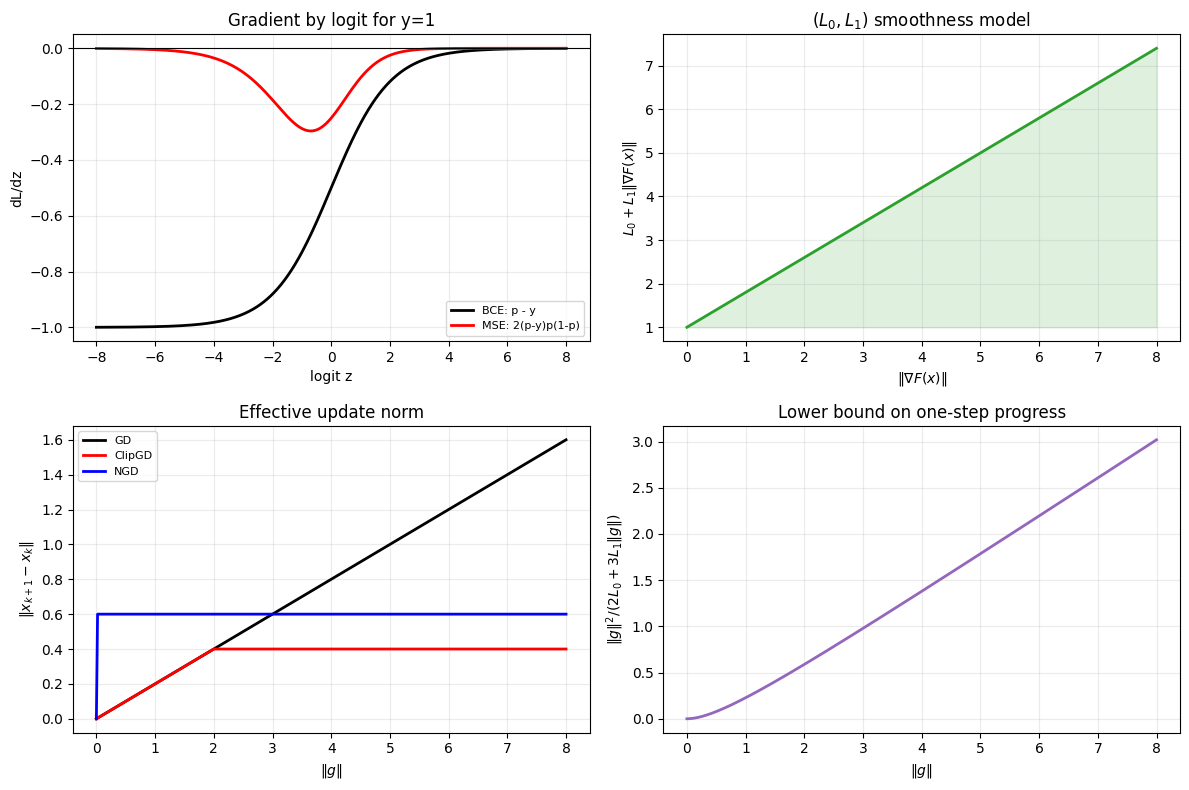

In [2]:
z_grid = np.linspace(-8, 8, 400)
p_grid = 1 / (1 + np.exp(-z_grid))
y_one = 1.0
grad_bce = p_grid - y_one
grad_mse = 2 * (p_grid - y_one) * p_grid * (1 - p_grid)

grad_norm_grid = np.linspace(0, 8, 400)
L0_demo, L1_demo = 1.0, 0.8
local_L = L0_demo + L1_demo * grad_norm_grid

lr_demo = 0.2
clip_radius_demo = 2.0
alpha_demo = 0.6
gd_update = lr_demo * grad_norm_grid
clip_update = lr_demo * np.minimum(grad_norm_grid, clip_radius_demo)
ngd_update = alpha_demo * grad_norm_grid / (grad_norm_grid + 1e-8)

progress = grad_norm_grid ** 2 / (2 * L0_demo + 3 * L1_demo * grad_norm_grid + 1e-12)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(z_grid, grad_bce, label="BCE: p - y", linewidth=2)
axes[0, 0].plot(z_grid, grad_mse, label="MSE: 2(p-y)p(1-p)", linewidth=2)
axes[0, 0].axhline(0, color="black", linewidth=0.8)
axes[0, 0].set_title("Gradient by logit for y=1")
axes[0, 0].set_xlabel("logit z")
axes[0, 0].set_ylabel("dL/dz")

axes[0, 1].plot(grad_norm_grid, local_L, color="tab:green", linewidth=2)
axes[0, 1].fill_between(grad_norm_grid, L0_demo, local_L, color="tab:green", alpha=0.15)
axes[0, 1].set_title(r"$(L_0,L_1)$ smoothness model")
axes[0, 1].set_xlabel(r"$\|\nabla F(x)\|$")
axes[0, 1].set_ylabel(r"$L_0 + L_1\|\nabla F(x)\|$")

axes[1, 0].plot(grad_norm_grid, gd_update, label="GD", linewidth=2)
axes[1, 0].plot(grad_norm_grid, clip_update, label="ClipGD", linewidth=2)
axes[1, 0].plot(grad_norm_grid, ngd_update, label="NGD", linewidth=2)
axes[1, 0].set_title("Effective update norm")
axes[1, 0].set_xlabel(r"$\|g\|$")
axes[1, 0].set_ylabel(r"$\|x_{k+1}-x_k\|$")

axes[1, 1].plot(grad_norm_grid, progress, color="tab:purple", linewidth=2)
axes[1, 1].set_title("Lower bound on one-step progress")
axes[1, 1].set_xlabel(r"$\|g\|$")
axes[1, 1].set_ylabel(r"$\|g\|^2/(2L_0+3L_1\|g\|)$")

for ax in axes.ravel():
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8) if ax.get_legend_handles_labels()[0] else None

plt.tight_layout()
plt.savefig(FIG_DIR / "part2_theory_visuals.png", dpi=160)
plt.show()

## Шаг 1. Данные `make_moons`

`sklearn` используется только как генератор данных и для метрик. Дальше вся сеть - на numpy. Признаки стандартизуем, метки делаем столбцом `(n, 1)`, тип - `float64` (для аккуратной проверки градиента конечными разностями).

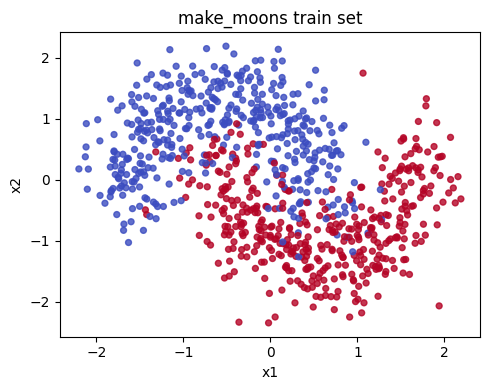

((840, 2), (360, 2))

In [3]:
X, y = make_moons(n_samples=1200, noise=0.25, random_state=SEED)
X = X.astype(np.float64)
y = y.astype(np.float64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Метки как столбцы (n, 1).
y_train_col = y_train.reshape(-1, 1)
y_test_col = y_test.reshape(-1, 1)

plt.figure(figsize=(5, 4))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", s=18, alpha=0.8)
plt.title("make_moons train set")
plt.xlabel("x1")
plt.ylabel("x2")
plt.tight_layout()
plt.savefig(FIG_DIR / "dataset_make_moons_part2.png", dpi=160)
plt.show()

X_train.shape, X_test.shape

## Шаг 2. Нейросеть на numpy - инициализация и прямой проход

Архитектура та же, что и в первой части: `2 -> 32 -> 32 -> 1`, активация `tanh`, на выходе один логит.

Параметры храним списками матриц `W` и векторов `b`. Инициализация - масштаб $1/\sqrt{n_{\text{in}}}$ (Xavier-подобная), bias нулевые. Прямой проход по слоям:

$$
z_1=XW_1+b_1,\;\; a_1=\tanh z_1,\qquad
z_2=a_1W_2+b_2,\;\; a_2=\tanh z_2,\qquad
z_3=a_2W_3+b_3\;(\text{логит}).
$$

Все промежуточные величины $X,a_1,a_2$ кэшируем - они понадобятся в обратном проходе.

In [4]:
LAYER_SIZES = [(2, 32), (32, 32), (32, 1)]


def init_params(seed=SEED):
    '''Детерминированная инициализация весов сети 2->32->32->1.'''
    rng = np.random.default_rng(seed)
    W, b = [], []
    for n_in, n_out in LAYER_SIZES:
        scale = 1.0 / np.sqrt(n_in)
        W.append(rng.standard_normal((n_in, n_out)) * scale)
        b.append(np.zeros((1, n_out)))
    return W, b


def forward(params, Xb):
    '''Прямой проход. Возвращает логиты (n,1) и кэш активаций для backprop.'''
    W, b = params
    a0 = Xb
    z1 = a0 @ W[0] + b[0]
    a1 = np.tanh(z1)
    z2 = a1 @ W[1] + b[1]
    a2 = np.tanh(z2)
    z3 = a2 @ W[2] + b[2]          # логиты, без активации
    cache = {"a0": a0, "a1": a1, "a2": a2}
    return z3, cache


# Быстрая проверка форм.
_p = init_params(SEED)
_logits, _cache = forward(_p, X_train)
print("logits shape:", _logits.shape, "(должно быть (n, 1))")

logits shape: (840, 1) (должно быть (n, 1))


## Шаг 3. Функция потерь BCE и её производная по логиту

Стабильная BCE-with-logits:

$$
F=\frac1n\sum_i\bigl(\operatorname{softplus}(z_i)-y_iz_i\bigr),
\qquad
\operatorname{softplus}(z)=\log(1+e^z).
$$

Производная по логиту - ровно $p-y$ (см. раздел 1), усредненная по батчу:

$$
\frac{\partial F}{\partial z_i}=\frac{1}{n}\bigl(\sigma(z_i)-y_i\bigr).
$$

`softplus` считаем через `np.logaddexp(0, z)` - это численно устойчиво и не переполняется при больших $z$.

In [5]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def bce_with_logits(logits, yb):
    '''Средняя BCE по батчу, устойчиво через softplus = logaddexp(0, z).'''
    return float(np.mean(np.logaddexp(0.0, logits) - yb * logits))


def dloss_dlogits(logits, yb):
    '''Производная средней BCE по логитам: (sigmoid(z) - y) / n.'''
    n = logits.shape[0]
    return (sigmoid(logits) - yb) / n

## Шаг 4. Обратный проход (backprop) вручную

Это центральное место - то, что autograd делает «незаметно», здесь выписано явно. Идем от выхода к входу. Обозначим $\delta_3=\partial F/\partial z_3=(\sigma(z_3)-y)/n$. Тогда по правилу цепочки:

$$
\frac{\partial F}{\partial W_3}=a_2^\top\delta_3,\qquad
\frac{\partial F}{\partial b_3}=\textstyle\sum_i (\delta_3)_i.
$$

Дальше пробрасываем градиент через `tanh` (производная $\tanh'(z)=1-\tanh^2 z=1-a^2$):

$$
\delta_2=(\delta_3 W_3^\top)\odot(1-a_2^2),\qquad
\frac{\partial F}{\partial W_2}=a_1^\top\delta_2,\quad
\frac{\partial F}{\partial b_2}=\textstyle\sum_i (\delta_2)_i,
$$

$$
\delta_1=(\delta_2 W_2^\top)\odot(1-a_1^2),\qquad
\frac{\partial F}{\partial W_1}=a_0^\top\delta_1,\quad
\frac{\partial F}{\partial b_1}=\textstyle\sum_i (\delta_1)_i.
$$

Функция `backward` возвращает градиенты в той же структуре, что и параметры (списки `dW`, `db`).

In [6]:
def backward(params, cache, logits, yb):
    '''Ручной backprop через сеть 2->32->32->1 с tanh. Возвращает (dW, db).'''
    W, b = params
    a0, a1, a2 = cache["a0"], cache["a1"], cache["a2"]

    d3 = dloss_dlogits(logits, yb)        # (n,1) = dF/dz3
    dW3 = a2.T @ d3
    db3 = d3.sum(axis=0, keepdims=True)

    d2 = (d3 @ W[2].T) * (1.0 - a2 ** 2)   # назад через tanh слоя 2
    dW2 = a1.T @ d2
    db2 = d2.sum(axis=0, keepdims=True)

    d1 = (d2 @ W[1].T) * (1.0 - a1 ** 2)   # назад через tanh слоя 1
    dW1 = a0.T @ d1
    db1 = d1.sum(axis=0, keepdims=True)

    return [dW1, dW2, dW3], [db1, db2, db3]

## Шаг 5. Плоский вектор параметров и сервисные функции

Оптимизаторы работают с параметрами как с одним вектором $\theta\in\mathbb{R}^d$. Поэтому заведем функции «параметры/градиент -> плоский вектор» и обратно. Порядок фиксированный: $W_1,b_1,W_2,b_2,W_3,b_3$.

`loss_and_grad` - единая точка, которая делает forward + backward и возвращает `(loss, плоский градиент)`. Никаких `detach`/`clone` (это были артефакты torch): в numpy достаточно `.copy()`, когда нужна независимая копия.

In [7]:
def flat_params(params):
    W, b = params
    chunks = []
    for i in range(len(W)):
        chunks.append(W[i].ravel())
        chunks.append(b[i].ravel())
    return np.concatenate(chunks)


def flat_to_params(vec):
    '''Обратное к flat_params: разворачиваем вектор в (W, b).'''
    W, b = [], []
    off = 0
    for n_in, n_out in LAYER_SIZES:
        w_size = n_in * n_out
        W.append(vec[off:off + w_size].reshape(n_in, n_out))
        off += w_size
        b.append(vec[off:off + n_out].reshape(1, n_out))
        off += n_out
    return W, b


def flat_grad(dW, db):
    chunks = []
    for i in range(len(dW)):
        chunks.append(dW[i].ravel())
        chunks.append(db[i].ravel())
    return np.concatenate(chunks)


NUM_PARAMS = flat_params(init_params(SEED)).size


def reset_model():
    '''Свежая модель с той же детерминированной инициализацией.'''
    return init_params(SEED)


def loss_and_grad(params, Xb=X_train, yb=y_train_col):
    '''Forward + backward на полном батче. Возвращает (loss, плоский градиент).'''
    logits, cache = forward(params, Xb)
    loss = bce_with_logits(logits, yb)
    dW, db = backward(params, cache, logits, yb)
    return loss, flat_grad(dW, db)


def loss_only(theta_flat, Xb=X_train, yb=y_train_col):
    '''Лосс по плоскому вектору параметров (нужно для line search и grad check).'''
    logits, _ = forward(flat_to_params(theta_flat), Xb)
    return bce_with_logits(logits, yb)


def evaluate(params):
    logits, _ = forward(params, X_test)
    probs = sigmoid(logits).ravel()
    preds = (probs >= 0.5).astype(np.float64)
    return {
        "accuracy": accuracy_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "log_loss": log_loss(y_test, np.clip(probs, 1e-7, 1 - 1e-7)),
    }

print("Число параметров сети d =", NUM_PARAMS)

Число параметров сети d = 1185


## Тест 1. Проверка backprop конечными разностями

Раньше корректность градиента «гарантировал» autograd. Теперь у нас явный backprop, поэтому проверяем его независимо - **центральной разностью**:

$$
\frac{\partial F}{\partial \theta_j}\approx
\frac{F(\theta+he_j)-F(\theta-he_j)}{2h}.
$$

Сравниваем с аналитическим градиентом из `backward`. Совпадение до ~$10^{-6}$ означает, что и формула производной BCE, и проброс через `tanh`-слои выписаны верно.

In [8]:
rng_check = np.random.default_rng(0)
theta0 = flat_params(init_params(SEED))

# Аналитический градиент.
_, g_analytic = loss_and_grad(flat_to_params(theta0))

# Численный градиент по случайной подвыборке координат (полный был бы дорогим).
idx = rng_check.choice(NUM_PARAMS, size=40, replace=False)
h = 1e-6
g_numeric = np.zeros_like(idx, dtype=np.float64)
for k, j in enumerate(idx):
    tp = theta0.copy(); tp[j] += h
    tm = theta0.copy(); tm[j] -= h
    g_numeric[k] = (loss_only(tp) - loss_only(tm)) / (2 * h)

max_abs_err = np.max(np.abs(g_analytic[idx] - g_numeric))
rel_err = max_abs_err / (np.max(np.abs(g_numeric)) + 1e-12)
print(f"max |analytic - numeric| = {max_abs_err:.2e}, rel = {rel_err:.2e}")
assert max_abs_err < 1e-5, "backprop расходится с конечными разностями"
print("OK: ручной backprop совпадает с численным градиентом.")

max |analytic - numeric| = 1.02e-10, rel = 1.89e-09
OK: ручной backprop совпадает с численным градиентом.


## Тест 2. Операторы clipping и normalization (numpy)

In [9]:
def clip_by_norm(g, c, eps=1e-12):
    '''Масштабируем g так, чтобы ||g|| не превышала c.'''
    norm = np.linalg.norm(g)
    scale = min(1.0, c / (norm + eps))
    return scale * g


g = np.array([3.0, 4.0])
clipped = clip_by_norm(g, 2.0)
assert np.isclose(np.linalg.norm(clipped), 2.0, atol=1e-6)

small = np.array([0.3, 0.4])
not_clipped = clip_by_norm(small, 2.0)
assert np.allclose(not_clipped, small, atol=1e-6)

alpha = 0.1
normalized_update = -alpha * g / np.linalg.norm(g)
assert np.isclose(np.linalg.norm(normalized_update), alpha, atol=1e-6)

print("OK: clipping и normalized update работают корректно.")

OK: clipping и normalized update работают корректно.


## Шаг 6. История обучения

В единый список истории на каждой итерации пишем: loss, норму градиента, длину фактического шага (`update_norm`), локальную оценку гладкости $\hat L_k$ и флаг clipping. Эти величины потом дают все графики и проверку `(L0,L1)`-гипотезы.

In [10]:
def _append_history(history, method, epoch, loss, grad, prev_grad, params_vec, prev_params,
                    update_norm, clipped):
    grad_norm = float(np.linalg.norm(grad))
    if prev_grad is None or prev_params is None:
        local_smoothness = np.nan
    else:
        dg = np.linalg.norm(grad - prev_grad)
        dx = np.linalg.norm(params_vec - prev_params)
        local_smoothness = float(dg / (dx + 1e-12))
    history.append({
        "method": method,
        "epoch": epoch,
        "loss": loss,
        "grad_norm": grad_norm,
        "update_norm": update_norm,
        "local_smoothness": local_smoothness,
        "clipped": clipped,
    })

## Шаг 7. Базовые методы: GD, ClipGD, NGD

Каждый метод - отдельная функция в своем шаге, чтобы было видно ровно одно правило обновления.

**GD:** $\theta_{k+1}=\theta_k-\eta g_k$.

In [11]:
def run_gd(epochs=250, lr=0.08):
    params = reset_model()
    history = []
    prev_grad = None
    prev_params = None

    for epoch in range(epochs):
        loss, grad = loss_and_grad(params)
        theta = flat_params(params)
        update = -lr * grad
        params = flat_to_params(theta + update)
        _append_history(history, "GD", epoch, loss, grad, prev_grad, theta, prev_params,
                        float(np.linalg.norm(update)), False)
        prev_grad = grad.copy()
        prev_params = theta.copy()
    return params, pd.DataFrame(history)

**ClipGD:** $\theta_{k+1}=\theta_k-\eta\,\operatorname{clip}_c(g_k)$. При $\|g_k\|>c$ длина градиента фиксируется на $c$.

In [12]:
def run_clip_gd(epochs=250, lr=0.08, clip_radius=1.0):
    params = reset_model()
    history = []
    prev_grad = None
    prev_params = None

    for epoch in range(epochs):
        loss, grad = loss_and_grad(params)
        theta = flat_params(params)
        clipped_grad = clip_by_norm(grad, clip_radius)
        update = -lr * clipped_grad
        params = flat_to_params(theta + update)
        was_clipped = bool(np.linalg.norm(grad) > clip_radius)
        _append_history(history, "ClipGD", epoch, loss, grad, prev_grad, theta, prev_params,
                        float(np.linalg.norm(update)), was_clipped)
        prev_grad = grad.copy()
        prev_params = theta.copy()
    return params, pd.DataFrame(history)

**NGD:** $\theta_{k+1}=\theta_k-\alpha\dfrac{g_k}{\|g_k\|+\beta}$ - шаг почти фиксированной длины $\alpha$.

In [13]:
def run_normalized_gd(epochs=250, alpha=0.035, beta=1e-8):
    params = reset_model()
    history = []
    prev_grad = None
    prev_params = None

    for epoch in range(epochs):
        loss, grad = loss_and_grad(params)
        theta = flat_params(params)
        update = -alpha * grad / (np.linalg.norm(grad) + beta)
        params = flat_to_params(theta + update)
        _append_history(history, "NGD", epoch, loss, grad, prev_grad, theta, prev_params,
                        float(np.linalg.norm(update)), False)
        prev_grad = grad.copy()
        prev_params = theta.copy()
    return params, pd.DataFrame(history)

## Шаг 8. NSGD-M (parameter-agnostic momentum + нормализация)

$m_k=\beta_km_{k-1}+(1-\beta_k)g_k$, $\theta_{k+1}=\theta_k-\eta_k m_k/\|m_k\|$ с расписанием $\beta_k=1-k^{-1/2}$, $\eta_k=0.12\,k^{-3/4}$.

In [14]:
def run_nsgdm(epochs=250):
    params = reset_model()
    history = []
    prev_grad = None
    prev_params = None
    m = None

    for epoch in range(1, epochs + 1):
        loss, grad = loss_and_grad(params)
        theta = flat_params(params)
        if m is None:
            m = np.zeros_like(grad)
        beta_t = 1.0 - epoch ** (-0.5)
        eta_t = 0.12 * epoch ** (-0.75)
        m = beta_t * m + (1.0 - beta_t) * grad
        update = -eta_t * m / (np.linalg.norm(m) + 1e-12)
        params = flat_to_params(theta + update)
        _append_history(history, "NSGD-M", epoch - 1, loss, grad, prev_grad, theta, prev_params,
                        float(np.linalg.norm(update)), False)
        prev_grad = grad.copy()
        prev_params = theta.copy()
    return params, pd.DataFrame(history)

## Шаг 9. Backtracking (Armijo) и шаг Поляка

**Backtracking:** уменьшаем $\eta$ в $\beta$ раз, пока не выполнится условие Armijo $F(\theta-\eta g)\le F(\theta)-\gamma\eta\|g\|^2$. Здесь явно пригождается `loss_only(theta)` - пробуем разные $\theta$ без перезаписи модели.

In [15]:
def run_backtracking_gd(epochs=250, eta0=1.0, beta=0.5, gamma=1e-4):
    params = reset_model()
    history = []
    prev_grad = None
    prev_params = None
    eta_prev = eta0

    for epoch in range(epochs):
        loss, grad = loss_and_grad(params)
        theta = flat_params(params)
        grad_sq = float(grad @ grad)
        eta = eta_prev

        while True:
            trial_loss = loss_only(theta - eta * grad)
            if trial_loss <= loss - gamma * eta * grad_sq or eta < 1e-8:
                break
            eta *= beta

        update = -eta * grad
        params = flat_to_params(theta + update)
        eta_prev = eta

        _append_history(history, "Backtracking", epoch, loss, grad, prev_grad, theta, prev_params,
                        float(np.linalg.norm(update)), False)
        history[-1]["eta"] = eta
        prev_grad = grad.copy()
        prev_params = theta.copy()
    return params, pd.DataFrame(history)

**Шаг Поляка:** $\eta_k=\dfrac{F(x_k)-F^*}{\|g_k\|^2}$, обрезанный сверху до `max_lr`.

Важный момент (и ответ на типичный вопрос «почему у Поляка норма градиента вылезает выше 1 и выше других методов»): мы берем `f_star=0.0`, но BCE на зашумленном `make_moons` (noise=0.25) **не может** дойти до нуля - реальный минимум заметно больше нуля из-за байесовской ошибки. Значит $(F-F^*)$ переоценивает зазор, шаг систематически слишком большой, метод перелетает минимум и попадает в области с большим градиентом. Поэтому `grad_norm` у Поляка осциллирует и может превышать 1 - это не нарушение (норма градиента вообще ничем не ограничена сверху), а прямое следствие заниженной $F^*$. Обрезка `max_lr` лишь частично это сдерживает.

In [16]:
def run_polyak(epochs=250, f_star=0.0, max_lr=1.0):
    params = reset_model()
    history = []
    prev_grad = None
    prev_params = None

    for epoch in range(epochs):
        loss, grad = loss_and_grad(params)
        theta = flat_params(params)
        grad_sq = float(grad @ grad)
        eta = max(0.0, min(max_lr, (loss - f_star) / (grad_sq + 1e-12)))
        update = -eta * grad
        params = flat_to_params(theta + update)
        _append_history(history, "Polyak", epoch, loss, grad, prev_grad, theta, prev_params,
                        float(np.linalg.norm(update)), False)
        history[-1]["eta"] = eta
        prev_grad = grad.copy()
        prev_params = theta.copy()
    return params, pd.DataFrame(history)

## Шаг 10. Адаптивный подбор `(L0, L1)` и шаги Vankov et al.

Это центральная часть второй части проекта. Под «усовершенствованными оценками» понимаются оценки с **адаптивно подбираемыми параметрами**. В методах выше параметры (`clip_radius`, `lr`, `alpha`) фиксированы заранее. Здесь мы наоборот **не знаем** `L0`, `L1` и оцениваем их прямо по траектории.

На каждой итерации доступна локальная оценка гладкости $\hat L_k=\dfrac{\|g_k-g_{k-1}\|}{\|x_k-x_{k-1}\|+\epsilon_{\mathrm{num}}}$. По модели `(L0,L1)` ожидается $\hat L_k\approx L_0+L_1\|g_k\|$. По скользящему окну делаем неотрицательную линейную регрессию

$$
(\hat L_{0,k},\hat L_{1,k})=\arg\min_{a,b\ge 0}\sum_{j}\bigl(\hat L_j-a-b\|g_j\|\bigr)^2,
$$

раздуваем коэффициентом безопасности и сглаживаем EMA. Затем используем шаги Vankov et al.:

- упрощенный шаг $\eta_k^{\mathrm{si}}=\dfrac{1}{\hat L_{0,k}+\frac32\hat L_{1,k}\|g_k\|}$ (метод `AdaptiveSI`);
- clipping-шаг $\eta_k^{\mathrm{cl}}=\min\!\left\{\dfrac{1}{2\hat L_{0,k}},\dfrac{1}{3\hat L_{1,k}\|g_k\|}\right\}$ (метод `AdaptiveClip`).

Оба шага определяются оценками по ходу обучения, а не вручную. Дополнительно шаг ограничен сверху `eta_max` для устойчивости.

In [17]:
class L0L1Estimator:
    '''Онлайн-оценка (L0, L1) по парам (||g||, L_hat) на скользящем окне.

    Неотрицательная регрессия L_hat ~ L0 + L1 * ||g||, раздув коэффициентом
    safety и сглаживание EMA -> устойчивая верхняя оценка локальной гладкости.
    '''

    def __init__(self, window=60, safety=1.1, L0_init=2.0, L1_init=1.0,
                 L0_floor=0.05, ema=0.3):
        self.gn = []
        self.lh = []
        self.window = window
        self.safety = safety
        self.L0 = L0_init
        self.L1 = L1_init
        self.L0_floor = L0_floor
        self.ema = ema

    def update(self, grad_norm, local_smoothness):
        if local_smoothness is not None and np.isfinite(local_smoothness):
            self.gn.append(float(grad_norm))
            self.lh.append(float(local_smoothness))
        gn = np.array(self.gn[-self.window:])
        lh = np.array(self.lh[-self.window:])
        if len(gn) >= 8 and np.ptp(gn) > 1e-3:
            A = np.column_stack([np.ones_like(gn), gn])
            sol, *_ = np.linalg.lstsq(A, lh, rcond=None)
            target_L0 = self.safety * max(float(sol[0]), self.L0_floor)
            target_L1 = self.safety * max(float(sol[1]), 0.0)
            self.L0 = (1 - self.ema) * self.L0 + self.ema * target_L0
            self.L1 = (1 - self.ema) * self.L1 + self.ema * target_L1
        return self.L0, self.L1


def run_adaptive_si(epochs=250, warmup=10, warmup_lr=0.05, eta_max=0.5):
    params = reset_model()
    history = []
    prev_grad = None
    prev_params = None
    est = L0L1Estimator()

    for epoch in range(epochs):
        loss, grad = loss_and_grad(params)
        theta = flat_params(params)
        grad_norm = float(np.linalg.norm(grad))
        if prev_grad is not None:
            dg = float(np.linalg.norm(grad - prev_grad))
            dx = float(np.linalg.norm(theta - prev_params))
            est.update(grad_norm, dg / (dx + 1e-12))
        L0, L1 = est.L0, est.L1
        eta_raw = 1.0 / (L0 + 1.5 * L1 * grad_norm + 1e-12)
        eta = warmup_lr if epoch < warmup else min(eta_max, eta_raw)
        update = -eta * grad
        params = flat_to_params(theta + update)
        _append_history(history, "AdaptiveSI", epoch, loss, grad, prev_grad, theta, prev_params,
                        float(np.linalg.norm(update)), False)
        history[-1]["eta"] = eta
        history[-1]["eta_raw"] = eta_raw
        history[-1]["L0_hat"] = L0
        history[-1]["L1_hat"] = L1
        prev_grad = grad.copy()
        prev_params = theta.copy()
    return params, pd.DataFrame(history)


def run_adaptive_clip(epochs=250, warmup=10, warmup_lr=0.05, eta_max=0.5):
    # Clipping-шаг Vankov et al.: eta_cl = min(1/(2 L0), 1/(3 L1 ||g||)),
    # где (L0, L1) оцениваются онлайн. При большом градиенте активна вторая
    # ветвь (длина update ~ 1/(3 L1)), при малом - первая (шаг ~ 1/(2 L0)).
    params = reset_model()
    history = []
    prev_grad = None
    prev_params = None
    est = L0L1Estimator()

    for epoch in range(epochs):
        loss, grad = loss_and_grad(params)
        theta = flat_params(params)
        grad_norm = float(np.linalg.norm(grad))
        if prev_grad is not None:
            dg = float(np.linalg.norm(grad - prev_grad))
            dx = float(np.linalg.norm(theta - prev_params))
            est.update(grad_norm, dg / (dx + 1e-12))
        L0, L1 = est.L0, est.L1
        eta_smooth = 1.0 / (2.0 * L0)
        eta_clip = 1.0 / (3.0 * L1 * grad_norm + 1e-12)
        eta_raw = min(eta_smooth, eta_clip)
        clip_active = bool(eta_clip < eta_smooth)
        if epoch < warmup:
            eta = warmup_lr
            clip_active = False
        else:
            eta = min(eta_max, eta_raw)
        update = -eta * grad
        params = flat_to_params(theta + update)
        _append_history(history, "AdaptiveClip", epoch, loss, grad, prev_grad, theta, prev_params,
                        float(np.linalg.norm(update)), clip_active)
        history[-1]["eta"] = eta
        history[-1]["eta_raw"] = eta_raw
        history[-1]["L0_hat"] = L0
        history[-1]["L1_hat"] = L1
        prev_grad = grad.copy()
        prev_params = theta.copy()
    return params, pd.DataFrame(history)

## Тест 3. Backtracking на квадратичной функции

In [18]:
def armijo_step_quadratic(x, L=5.0, eta0=1.0, beta=0.5, gamma=1e-4):
    f = lambda z: 0.5 * L * z ** 2
    grad = L * x
    eta = eta0
    while f(x - eta * grad) > f(x) - gamma * eta * grad ** 2:
        eta *= beta
    return eta, f(x), f(x - eta * grad)


eta, before, after = armijo_step_quadratic(2.0)
assert after < before
assert eta > 0
print("OK: Armijo backtracking уменьшает квадратичную функцию.")

OK: Armijo backtracking уменьшает квадратичную функцию.


## Шаг 11. Запуск всех методов

In [19]:
runs = []
models = {}

for name, runner in [
    ("GD", lambda: run_gd(epochs=250, lr=0.08)),
    ("ClipGD", lambda: run_clip_gd(epochs=250, lr=0.08, clip_radius=0.35)),
    ("NGD", lambda: run_normalized_gd(epochs=250, alpha=0.035)),
    ("NSGD-M", lambda: run_nsgdm(epochs=250)),
    ("Backtracking", lambda: run_backtracking_gd(epochs=250, eta0=1.0)),
    ("Polyak", lambda: run_polyak(epochs=250, f_star=0.0, max_lr=1.0)),
    ("AdaptiveSI", lambda: run_adaptive_si(epochs=250)),
    ("AdaptiveClip", lambda: run_adaptive_clip(epochs=250)),
]:
    model, hist = runner()
    models[name] = model
    runs.append(hist)

history = pd.concat(runs, ignore_index=True)

metrics = []
for name, model in models.items():
    row = {"method": name}
    row.update(evaluate(model))
    final_hist = history[history["method"] == name].iloc[-1]
    row["final_train_loss"] = final_hist["loss"]
    row["final_grad_norm"] = final_hist["grad_norm"]
    row["mean_update_norm"] = history[history["method"] == name]["update_norm"].mean()
    row["clip_rate"] = history[history["method"] == name]["clipped"].mean()
    metrics.append(row)

metrics_df = pd.DataFrame(metrics).sort_values(["log_loss", "final_train_loss"])
metrics_df

,method,accuracy,f1,log_loss,final_train_loss,final_grad_norm,mean_update_norm,clip_rate
4,Backtracking,0.950000,0.949438,0.134766,0.172119,0.005274,0.022486,0.000
2,NGD,0.952778,0.952113,0.136344,0.173134,0.063177,0.035000,0.000
6,AdaptiveSI,0.950000,0.949438,0.139045,0.174754,0.009227,0.019596,0.000
7,AdaptiveClip,0.950000,0.949438,0.139118,0.174796,0.009299,0.019573,0.268
5,Polyak,0.950000,0.948864,0.145216,0.183265,0.179727,0.165079,0.000
0,GD,0.891667,0.888889,0.272065,0.287121,0.057990,0.007722,0.000
1,ClipGD,0.888889,0.886364,0.273868,0.288842,0.057978,0.007588,0.072
3,NSGD-M,0.883333,0.880000,0.300560,0.314446,0.056584,0.005987,0.000


## Тест 4. Методы должны обучаться

- loss у каждого метода уменьшился;
- хотя бы несколько методов дали accuracy выше 0.85;
- таблица метрик без NaN.

In [20]:
for method in history["method"].unique():
    h = history[history["method"] == method]
    assert h["loss"].iloc[-1] < h["loss"].iloc[0], f"{method}: loss did not decrease"

assert metrics_df["accuracy"].isna().sum() == 0
assert (metrics_df["accuracy"] >= 0.85).sum() >= 3

print("OK: optimization tests passed.")

OK: optimization tests passed.


## Графики обучения

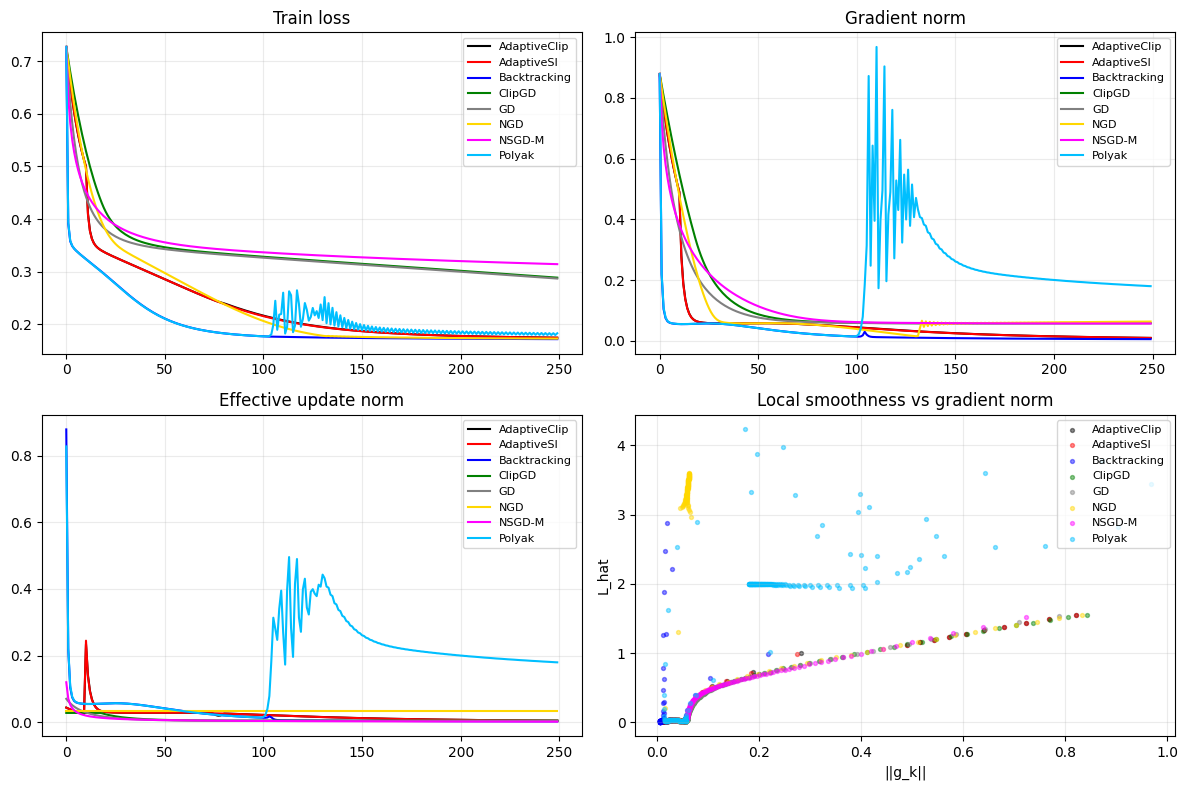

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for method, h in history.groupby("method"):
    axes[0, 0].plot(h["epoch"], h["loss"], label=method)
    axes[0, 1].plot(h["epoch"], h["grad_norm"], label=method)
    axes[1, 0].plot(h["epoch"], h["update_norm"], label=method)

smooth = history.dropna(subset=["local_smoothness"])
for method, h in smooth.groupby("method"):
    axes[1, 1].scatter(h["grad_norm"], h["local_smoothness"], s=8, alpha=0.45, label=method)

axes[0, 0].set_title("Train loss")
axes[0, 1].set_title("Gradient norm")
axes[1, 0].set_title("Effective update norm")
axes[1, 1].set_title("Local smoothness vs gradient norm")

for ax in axes.ravel():
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

axes[1, 1].set_xlabel("||g_k||")
axes[1, 1].set_ylabel("L_hat")
plt.tight_layout()
plt.savefig(FIG_DIR / "part2_optimizer_comparison.png", dpi=160)
plt.show()

## Проверка `(L0, L1)`-гипотезы по траектории

Оцениваем корреляцию между локальной гладкостью $\hat L_k$ и нормой градиента $\|g_k\|$. Положительная корреляция не доказывает условие строго, но является эмпирическим признаком, что модель $\hat L_k \approx L_0 + L_1\|g_k\|$ имеет смысл для данной задачи.

**Важно про знак.** В таблице ниже столбец `corr(L_hat, ||g||)` - это **коэффициент корреляции**, он законно лежит в $[-1,1]$ и **может быть отрицательным**. Это не норма (нормы $\hat L_k$, $\|g_k\|$, длины шага всегда $\ge 0$). Отрицательное значение у NGD - не ошибка: NGD делает шаг почти фиксированной длины $\|x_k-x_{k-1}\|\approx\alpha$, поэтому знаменатель в $\hat L_k$ почти постоянен и не растет вместе с $\|g_k\|$; вблизи минимума норма градиента падает, но фиксированный шаг заставляет траекторию колебаться, и $\hat L_k$ оказывается даже больше при малых $\|g_k\|$. Поэтому траекторная проверка `(L0,L1)` информативна для методов с шагом, зависящим от градиента (GD, ClipGD, AdaptiveSI/AdaptiveClip), а не для чисто нормализованного шага.

In [22]:
corr_rows = []
for method, h in history.dropna(subset=["local_smoothness"]).groupby("method"):
    if len(h) < 3:
        corr = np.nan
        l0 = np.nan
        l1 = np.nan
    else:
        corr = h[["grad_norm", "local_smoothness"]].corr().iloc[0, 1]
        x = h["grad_norm"].to_numpy()
        y_l = h["local_smoothness"].to_numpy()
        A = np.column_stack([np.ones_like(x), x])
        l0, l1 = np.linalg.lstsq(A, y_l, rcond=None)[0]
    corr_rows.append({
        "method": method,
        "corr(L_hat, ||g||)": corr,
        "fit_L0": max(0.0, l0) if not np.isnan(l0) else np.nan,
        "fit_L1": max(0.0, l1) if not np.isnan(l1) else np.nan,
    })

corr_df = pd.DataFrame(corr_rows).sort_values("corr(L_hat, ||g||)", ascending=False)
corr_df

,method,"corr(L_hat, ||g||)",fit_L0,fit_L1
1,AdaptiveSI,0.968677,0.000000,2.130451
0,AdaptiveClip,0.968622,0.000000,2.132287
3,ClipGD,0.934327,0.000000,2.261400
4,GD,0.919232,0.000000,2.528786
6,NSGD-M,0.916616,0.000000,2.664874
7,Polyak,0.772879,0.382074,5.328159
2,Backtracking,0.132693,0.048081,1.927323
5,NGD,-0.041677,1.763328,0.000000


## Тест 5. Локальная гладкость считается корректно

Все величины-нормы неотрицательны (это и есть строгий ответ на вопрос «может ли норма быть отрицательной» - нет).

In [23]:
assert history["grad_norm"].gt(0).all()
assert history["update_norm"].ge(0).all()
assert history["local_smoothness"].dropna().ge(0).all()
assert len(corr_df) == history["method"].nunique()

print("OK: local smoothness diagnostics are valid.")

OK: local smoothness diagnostics are valid.


## Адаптивные параметры: оценки `(L0, L1)` и шаг по траектории

Для `AdaptiveSI` и `AdaptiveClip` параметры не заданы заранее, а оцениваются онлайн. Ниже видно, как меняются $\hat L_{0,k}$, $\hat L_{1,k}$ и сам адаптивный шаг. После warmup метод полностью опирается на собственные оценки.

На правой панели - **сырой** (до ограничения сверху) адаптивный шаг в логарифмическом масштабе. В начале обучения, когда $\|g_k\|$ велика, шаг мал (защита $\sim 1/(\hat L_1\|g_k\|)$), а по мере уменьшения градиента он растет. На простой задаче `make_moons` оценки $\hat L_0,\hat L_1$ малы, поэтому оптимальный шаг быстро превышает потолок `eta_max=0.5` (горизонтальная линия): адаптивность здесь работает в основном как защита от больших градиентов в начале.

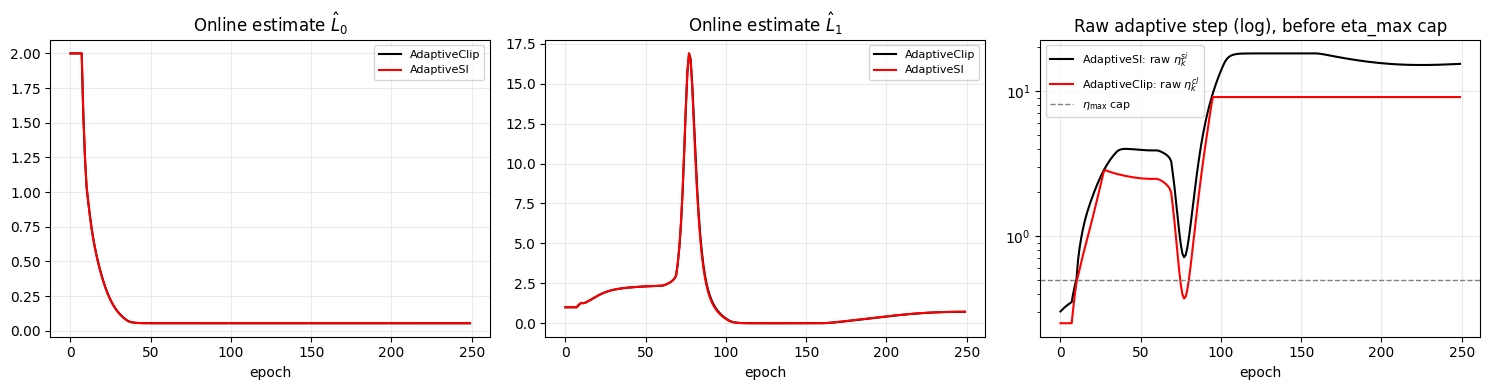

In [24]:
adaptive_methods = ["AdaptiveSI", "AdaptiveClip"]
adp = history[history["method"].isin(adaptive_methods)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for method, h in adp.groupby("method"):
    axes[0].plot(h["epoch"], h["L0_hat"], label=method)
    axes[1].plot(h["epoch"], h["L1_hat"], label=method)

si = history[history["method"] == "AdaptiveSI"]
ac = history[history["method"] == "AdaptiveClip"]
axes[2].plot(si["epoch"], si["eta_raw"], label=r"AdaptiveSI: raw $\eta_k^{si}$")
axes[2].plot(ac["epoch"], ac["eta_raw"], label=r"AdaptiveClip: raw $\eta_k^{cl}$")
axes[2].axhline(0.5, color="gray", linestyle="--", linewidth=1, label=r"$\eta_{\max}$ cap")
axes[2].set_yscale("log")

axes[0].set_title(r"Online estimate $\hat L_0$")
axes[1].set_title(r"Online estimate $\hat L_1$")
axes[2].set_title("Raw adaptive step (log), before eta_max cap")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "part2_adaptive_params.png", dpi=160)
plt.show()

## Тест 6. Адаптивные методы дают валидные параметры и обучаются

In [25]:
for method in adaptive_methods:
    h = history[history["method"] == method]
    assert h["L0_hat"].ge(0).all(), f"{method}: negative L0_hat"
    assert h["L1_hat"].ge(0).all(), f"{method}: negative L1_hat"
    assert h["eta"].gt(0).all(), f"{method}: non-positive step"
    assert h["eta"].le(0.5 + 1e-9).all(), f"{method}: step exceeds eta_max"
    assert h["loss"].iloc[-1] < h["loss"].iloc[0], f"{method}: loss did not decrease"

print("OK: adaptive (L0, L1) methods produce valid parameters and train.")

OK: adaptive (L0, L1) methods produce valid parameters and train.


## Учет неточности используемой информации

Улучшенные оценки должны учитывать **неточность используемой информации**. Моделируем неточный оракул градиента:

$$
\tilde g_k=\nabla F(x_k)+\xi_k+b_k,
\qquad
\mathbb{E}\|\xi_k\|^2\le \sigma^2,
\qquad
\|b_k\|\le \delta_k.
$$

Здесь $\xi_k$ - несмещенный шум (масштаб $\sigma$ на координату), $b_k$ - смещение нормы $\|b_k\|=\rho\|\nabla F(x_k)\|$. Берем **худшее (противонаправленное)** смещение $b_k=-\rho\nabla F(x_k)$, то есть $\tilde g_k=(1-\rho)\nabla F(x_k)$: именно этот случай отвечает оценке $\langle \nabla F(x_k),\tilde g_k\rangle\ge (1-\rho)\|\nabla F(x_k)\|^2$, гарантирующей спуск только при $\rho<1$.

Теория предсказывает шумовой пол $\|\nabla F(x)\|\lesssim \varepsilon+C_1\sigma+C_2\delta$. Запускаем GD, ClipGD, NGD с зашумленным градиентом при разных $\sigma$ и смотрим на **истинную** норму градиента (до добавления шума). NGD делает шаг почти фиксированной длины, поэтому имеет собственный ненулевой пол даже при $\sigma=0$.

In [26]:
def make_inexact_oracle(sigma=0.0, rel_bias=0.0, seed=0):
    rng = np.random.default_rng(seed)

    def oracle(params):
        loss, grad = loss_and_grad(params)
        true_norm = float(np.linalg.norm(grad))
        g = grad.copy()
        if sigma > 0:
            g = g + rng.standard_normal(grad.shape[0]) * sigma
        if rel_bias > 0:
            # Худшее (противонаправленное) смещение: g_tilde = (1 - rho) * grad.
            g = g - rel_bias * grad
        return loss, g, true_norm

    return oracle


def run_with_oracle(method, oracle, epochs=200, **kw):
    params = reset_model()
    rows = []
    for epoch in range(epochs):
        loss, g, true_norm = oracle(params)
        theta = flat_params(params)
        gnorm = float(np.linalg.norm(g))
        if method == "GD":
            update = -kw.get("lr", 0.08) * g
        elif method == "ClipGD":
            cg = clip_by_norm(g, kw.get("c", 0.35))
            update = -kw.get("lr", 0.08) * cg
        elif method == "NGD":
            update = -kw.get("alpha", 0.035) * g / (gnorm + 1e-8)
        else:
            raise ValueError(method)
        params = flat_to_params(theta + update)
        rows.append({
            "method": method,
            "epoch": epoch,
            "loss": loss,
            "true_grad_norm": true_norm,
            "obs_grad_norm": gnorm,
        })
    return params, pd.DataFrame(rows)


sigmas = [0.0, 0.01, 0.03, 0.1, 0.3]
oracle_methods = [("GD", {"lr": 0.08}), ("ClipGD", {"lr": 0.08, "c": 0.35}), ("NGD", {"alpha": 0.035})]

floor_rows = []
for sigma in sigmas:
    for method, kw in oracle_methods:
        _, h = run_with_oracle(method, make_inexact_oracle(sigma=sigma, seed=0), epochs=200, **kw)
        tail = float(h["true_grad_norm"].tail(20).mean())
        floor_rows.append({"method": method, "sigma": sigma, "floor_grad_norm": tail})

floor_df = pd.DataFrame(floor_rows)
floor_pivot = floor_df.pivot(index="sigma", columns="method", values="floor_grad_norm")
floor_pivot

method,ClipGD,GD,NGD
sigma,,,
0.00,0.057459,0.057497,0.059985
0.01,0.058024,0.058116,0.058469
0.03,0.067181,0.059882,0.062012
0.10,0.213536,0.073340,0.168050
0.30,0.484448,0.171849,0.427041


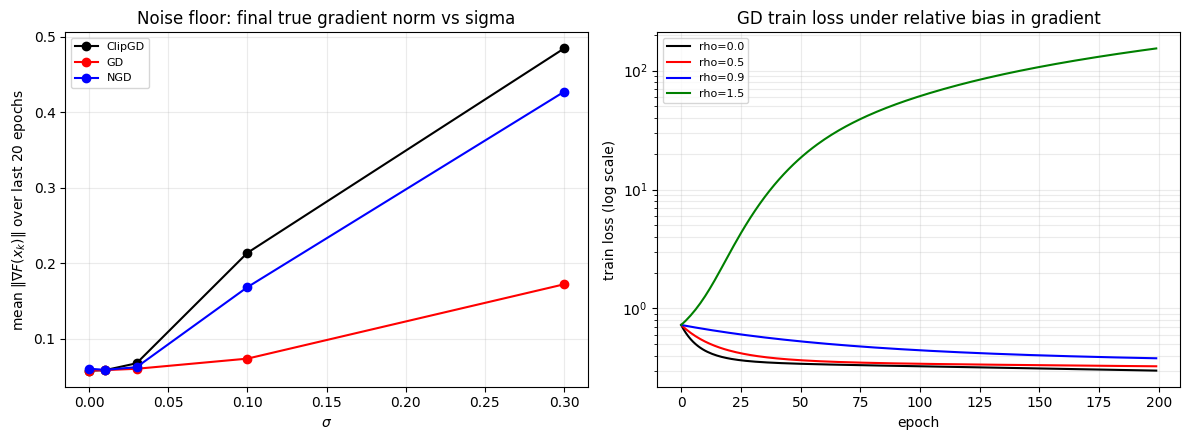

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for method in floor_pivot.columns:
    axes[0].plot(floor_pivot.index, floor_pivot[method], marker="o", label=method)
axes[0].set_title("Noise floor: final true gradient norm vs sigma")
axes[0].set_xlabel(r"$\sigma$")
axes[0].set_ylabel(r"mean $\|\nabla F(x_k)\|$ over last 20 epochs")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

# Relative bias: descent holds while rho < 1, can break for rho >= 1.
for rho in [0.0, 0.5, 0.9, 1.5]:
    _, h = run_with_oracle("GD", make_inexact_oracle(sigma=0.0, rel_bias=rho, seed=0), epochs=200, lr=0.08)
    axes[1].plot(h["epoch"], h["loss"], label=f"rho={rho}")
axes[1].set_title("GD train loss under relative bias in gradient")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("train loss (log scale)")
axes[1].set_yscale("log")
axes[1].grid(alpha=0.25, which="both")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "part2_inexact_information.png", dpi=160)
plt.show()

## Тест 7. Шумовой пол растет с уровнем шума

In [28]:
for method in floor_pivot.columns:
    assert floor_pivot[method].loc[0.3] > floor_pivot[method].loc[0.0], \
        f"{method}: noise floor did not grow with sigma"

# rho < 1: loss still decreases; rho > 1: anti-aligned bias breaks descent.
_, h_ok = run_with_oracle("GD", make_inexact_oracle(rel_bias=0.9, seed=0), epochs=200, lr=0.08)
assert h_ok["loss"].iloc[-1] < h_ok["loss"].iloc[0], "GD with rho=0.9 should still decrease loss"

_, h_bad = run_with_oracle("GD", make_inexact_oracle(rel_bias=1.5, seed=0), epochs=200, lr=0.08)
assert h_bad["loss"].iloc[-1] > h_bad["loss"].iloc[0], "GD with rho=1.5 should lose the descent guarantee"

print("OK: noise floor grows with sigma; rho<1 keeps descent, rho>1 breaks it.")

OK: noise floor grows with sigma; rho<1 keeps descent, rho>1 breaks it.


## Сравнение оценок скорости сходимости

Используя оценки $\hat L_0,\hat L_1$ из траектории GD и начальный разрыв $F_0=F(x_0)-F^*$ ($F^*\approx 0$), сравним три оценки числа итераций для $\|\nabla F\|\le \varepsilon$:

- **старая** оценка clipped GD (Zhang et al.): $\;O\!\left(\dfrac{L_0\Delta_0}{\varepsilon^2}+\dfrac{L_1^2\Delta_0}{L_0}\right)$;
- **улучшенная** невыпуклая оценка (Vankov et al.): $\;O\!\left(\dfrac{L_0F_0}{\varepsilon^2}+\dfrac{L_1F_0}{\varepsilon}\right)$;
- **parameter-agnostic** NSGD-M: $\;\tilde O(\varepsilon^{-4})$.

Улучшение - замена члена $L_1^2\Delta_0/L_0$ (константа, не убывающая по $\varepsilon$) на $L_1F_0/\varepsilon$, который ведет себя лучше при умеренных $L_1$ и не требует верхней оценки $M=\sup\|\nabla F\|$.

Fitted from GD trajectory: L0 ~ 0.010, L1 ~ 2.529, F0 ~ 0.727


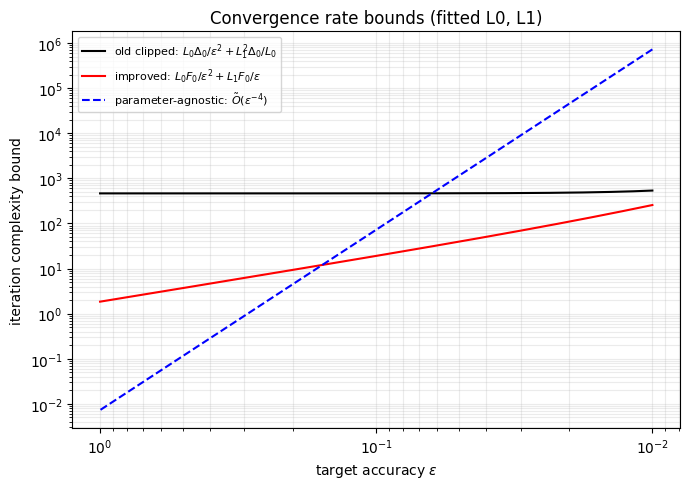

,old,improved
epsilon,,
0.30,464.834597,6.206932
0.10,465.480617,19.105310
0.05,467.660937,39.664166


In [29]:
gd_hist = history[history["method"] == "GD"].dropna(subset=["local_smoothness"])
xg = gd_hist["grad_norm"].to_numpy()
yg = gd_hist["local_smoothness"].to_numpy()
A = np.column_stack([np.ones_like(xg), xg])
sol, *_ = np.linalg.lstsq(A, yg, rcond=None)
L0_fit = max(float(sol[0]), 1e-2)
L1_fit = max(float(sol[1]), 1e-3)
F0 = float(history[history["method"] == "GD"]["loss"].iloc[0])

print(f"Fitted from GD trajectory: L0 ~ {L0_fit:.3f}, L1 ~ {L1_fit:.3f}, F0 ~ {F0:.3f}")

eps = np.logspace(-2, 0, 200)
bound_old = L0_fit * F0 / eps ** 2 + (L1_fit ** 2) * F0 / L0_fit
bound_improved = L0_fit * F0 / eps ** 2 + L1_fit * F0 / eps
bound_pa = (L0_fit * F0) / eps ** 4

plt.figure(figsize=(7, 5))
plt.loglog(eps, bound_old, label=r"old clipped: $L_0\Delta_0/\varepsilon^2+L_1^2\Delta_0/L_0$")
plt.loglog(eps, bound_improved, label=r"improved: $L_0F_0/\varepsilon^2+L_1F_0/\varepsilon$")
plt.loglog(eps, bound_pa, "--", label=r"parameter-agnostic: $\tilde O(\varepsilon^{-4})$")
plt.gca().invert_xaxis()
plt.xlabel(r"target accuracy $\varepsilon$")
plt.ylabel("iteration complexity bound")
plt.title("Convergence rate bounds (fitted L0, L1)")
plt.grid(alpha=0.25, which="both")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "part2_convergence_bounds.png", dpi=160)
plt.show()

bound_table = pd.DataFrame({
    "epsilon": [0.3, 0.1, 0.05],
    "old": [L0_fit * F0 / e ** 2 + (L1_fit ** 2) * F0 / L0_fit for e in [0.3, 0.1, 0.05]],
    "improved": [L0_fit * F0 / e ** 2 + L1_fit * F0 / e for e in [0.3, 0.1, 0.05]],
}).set_index("epsilon")
bound_table

## Проверка устойчивости на нескольких seed

Как и в первой части, проверяем результаты на нескольких случайных запусках. Для каждого seed заново генерируются данные `make_moons` и инициализация сети. Сравниваем GD, ClipGD, NGD и адаптивный `AdaptiveSI` по test accuracy и F1.

In [30]:
def build_problem(seed):
    Xs, ys = make_moons(n_samples=1200, noise=0.25, random_state=seed)
    Xs = Xs.astype(np.float64)
    ys = ys.astype(np.float64)
    Xtr, Xte, ytr, yte = train_test_split(Xs, ys, test_size=0.30, random_state=seed, stratify=ys)
    sc = StandardScaler()
    Xtr = sc.fit_transform(Xtr)
    Xte = sc.transform(Xte)
    return Xtr, ytr.reshape(-1, 1), Xte, yte


def seed_train(method, seed, epochs=150):
    params = init_params(seed)
    Xtr, ytr, Xte, yte = build_problem(seed)
    est = L0L1Estimator()
    prev_g = None
    prev_x = None

    for epoch in range(epochs):
        _, g = loss_and_grad(params, Xtr, ytr)
        x = flat_params(params)
        gn = float(np.linalg.norm(g))
        if method == "GD":
            upd = -0.08 * g
        elif method == "ClipGD":
            upd = -0.08 * clip_by_norm(g, 0.35)
        elif method == "NGD":
            upd = -0.035 * g / (gn + 1e-8)
        elif method == "AdaptiveSI":
            if prev_g is not None:
                dg = float(np.linalg.norm(g - prev_g))
                dx = float(np.linalg.norm(x - prev_x))
                est.update(gn, dg / (dx + 1e-12))
            eta = 0.05 if epoch < 10 else min(0.5, 1.0 / (est.L0 + 1.5 * est.L1 * gn + 1e-12))
            upd = -eta * g
        else:
            raise ValueError(method)
        params = flat_to_params(x + upd)
        prev_g = g.copy()
        prev_x = x.copy()

    logits, _ = forward(params, Xte)
    probs = sigmoid(logits).ravel()
    preds = (probs >= 0.5).astype(np.float64)
    return accuracy_score(yte, preds), f1_score(yte, preds)


seeds = list(range(10))
ms_rows = []
for method in ["GD", "ClipGD", "NGD", "AdaptiveSI"]:
    for s in seeds:
        acc, f1 = seed_train(method, s)
        ms_rows.append({"method": method, "seed": s, "accuracy": acc, "f1": f1})

ms_df = pd.DataFrame(ms_rows)
ms_summary = ms_df.groupby("method")[["accuracy", "f1"]].agg(["mean", "std"])
ms_summary

accuracy                  f1          
                mean       std      mean       std
method                                            
AdaptiveSI  0.945000  0.010294  0.944818  0.010741
ClipGD      0.881944  0.012090  0.882003  0.013054
GD          0.883333  0.010956  0.883379  0.011754
NGD         0.941944  0.010754  0.941803  0.011231

C:\Users\daeris\AppData\Local\Temp\ipykernel_18628\4217156897.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(acc_data, labels=order)
C:\Users\daeris\AppData\Local\Temp\ipykernel_18628\4217156897.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(f1_data, labels=order)


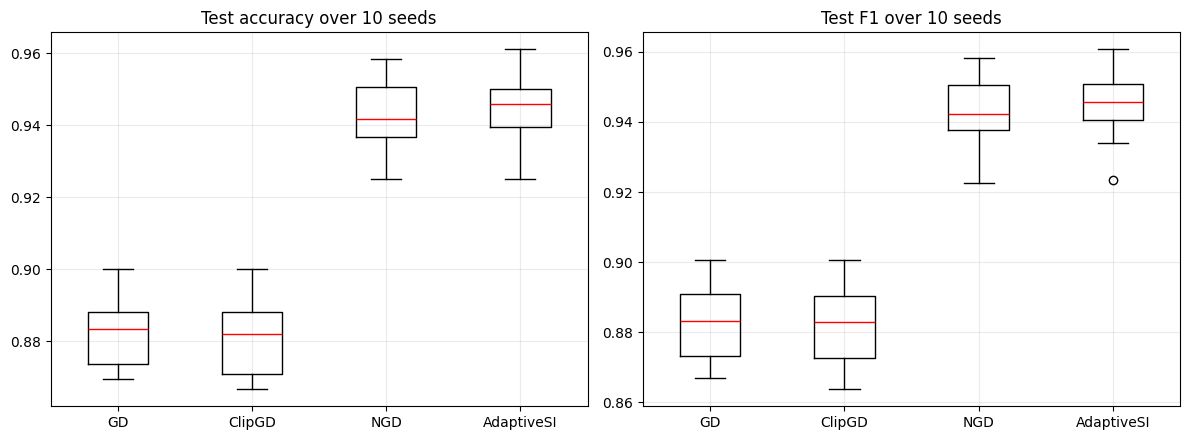

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
order = ["GD", "ClipGD", "NGD", "AdaptiveSI"]
acc_data = [ms_df[ms_df["method"] == m]["accuracy"].to_numpy() for m in order]
f1_data = [ms_df[ms_df["method"] == m]["f1"].to_numpy() for m in order]
axes[0].boxplot(acc_data, labels=order)
axes[0].set_title(f"Test accuracy over {len(seeds)} seeds")
axes[0].grid(alpha=0.25)
axes[1].boxplot(f1_data, labels=order)
axes[1].set_title(f"Test F1 over {len(seeds)} seeds")
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "part2_multiseed.png", dpi=160)
plt.show()

## Тест 8. Многосидовая проверка

In [32]:
assert ms_df["accuracy"].mean() > 0.85, "average accuracy across seeds is too low"
for method in order:
    m_acc = ms_df[ms_df["method"] == method]["accuracy"].mean()
    assert m_acc > 0.8, f"{method}: mean accuracy {m_acc:.3f} too low"

print("OK: all methods are robust across seeds.")

OK: all methods are robust across seeds.


## Вывод

В этом notebook нейросеть реализована **с нуля на numpy**: явная инициализация, явный прямой проход и явный backprop (Шаги 2-5), корректность которого подтверждена проверкой конечными разностями (Тест 1). Никакого `torch` и autograd - каждый шаг градиента виден и проверяем. На этой сети проведено сравнение методов оптимизации, связанных с `(L0, L1)`-гладкостью, на задаче `make_moons`.

Базовое сравнение методов:

- `ClipGD` ограничивает длину шага при больших градиентах и стабилизирует обучение;
- `NGD` делает шаг почти фиксированной длины, поэтому тоже защищается от резких областей;
- `NSGD-M` - parameter-agnostic вариант с momentum и нормализацией;
- `Backtracking` подбирает шаг через условие Armijo и не требует знать `L0`, `L1`;
- `Polyak` хорош при разумной нижней оценке `F*`; при заниженной `F*` (здесь `f_star=0`) шаг систематически велик, и норма градиента растет/осциллирует (это видно на графике Gradient norm);
- `corr(L_hat, ||g||)` показывает, насколько на этой задаче видна идея `(L0, L1)`-гладкости (и это корреляция, а не норма - знак может быть любым).

Две темы, отмеченные отдельно:

1. **Адаптивно подбираемые параметры.** `AdaptiveSI` и `AdaptiveClip` не используют заранее заданные `L0`, `L1`: они оценивают их онлайн по траектории (регрессия $\hat L_k\approx L_0+L_1\|g_k\|$ на скользящем окне) и из этих оценок считают шаг. См. `part2_adaptive_params.png`.

2. **Учет неточности информации.** При зашумленном/смещенном градиенте наблюдается шумовой пол: достижимая норма градиента растет с $\sigma$ (`part2_inexact_information.png`); относительное смещение $\rho<1$ сохраняет спуск, $\rho\ge 1$ разрушает. Это согласуется с $\|\nabla F\|\lesssim \varepsilon+C_1\sigma+C_2\delta$.

Сравнение оценок (`part2_convergence_bounds.png`): улучшенная оценка Vankov et al. $O(L_0F_0/\varepsilon^2+L_1F_0/\varepsilon)$ заменяет плохой член $L_1^2\Delta_0/L_0$ на более мягкий $L_1F_0/\varepsilon$. Многосидовая проверка (`part2_multiseed.png`) подтверждает устойчивость выводов.

Для отчета: таблицы `metrics_df`, `corr_df`, `floor_pivot`, `bound_table`, `ms_summary` и графики из `figures_part2/`.